Code for Subsection 3.2. Artificial Example

In [1]:
# ============================================================
# Experiment 1. Path of Expected Excess Risk for tSGHMC and TUSLA
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from Algorithms import TamedSGHMC, TUSLA


# ------------------------------
# Problem setup
# ------------------------------
d = 20
eps = 0.05
eta_nl = 0.1

mu_vec = np.full(d, eps, dtype=float)
mu_vec[0] = 1.0
A = np.diag(mu_vec)

rng_problem = np.random.default_rng(20260423)
v = rng_problem.normal(0.0, 1.0, size=d)
v = v / np.linalg.norm(v)
B = np.outer(v, v)

sigma_x = 1


def U(theta, x):
    """Stochastic objective U(theta, x)."""
    theta = np.asarray(theta, dtype=float)
    x = np.asarray(x, dtype=float)

    quad = 0.5 * float(theta @ (A @ theta))
    quartic = 0.25 * eta_nl * float(theta @ (B @ theta)) ** 2
    linear = float(x @ theta)

    return quad + quartic + linear


def H(theta, x):
    """Gradient estimator of U(theta, x)."""
    theta = np.asarray(theta, dtype=float)
    x = np.asarray(x, dtype=float)

    bt = float(theta @ (B @ theta))

    return A @ theta + eta_nl * bt * (B @ theta) + x


def sample_x(rng, n):
    """Sample stochastic data/noise terms."""
    return rng.normal(0.0, sigma_x, size=(n, d))


# ------------------------------
# Shared parameters
# ------------------------------
lr_shared = 1e-3
beta_shared = 1e10
r_shared = 2.0

# tSGHMC-specific parameters
gamma_tamed = 1.0
m_tamed = eps

n_iters = 10**5
n_repeats = 30

# Theoretical optimum:
# inf E[U(theta, X)] = 0 at theta* = 0
U_star = 0.0


def run_excess_risk_experiment():
    """Run repeated simulations and return excess-risk trajectories."""
    all_excess_tusla = np.zeros((n_repeats, n_iters + 1), dtype=float)
    all_excess_tamed = np.zeros((n_repeats, n_iters + 1), dtype=float)

    x_eval = np.zeros(d, dtype=float)

    for rep in range(n_repeats):
        rng_data = np.random.default_rng(12000 + rep)
        rng_tusla = np.random.default_rng(22000 + rep)
        rng_tamed = np.random.default_rng(32000 + rep)

        xs = sample_x(rng_data, n_iters)

        # Shared initial point, independent of data
        theta0 = np.random.default_rng(42000 + rep).normal(0.0, 1.0, size=d)

        theta_tusla = theta0.copy()
        theta_tamed = theta0.copy()
        vol_tamed = np.zeros(d, dtype=float)

        solver_tusla = TUSLA(
            H=H,
            lr=lr_shared,
            beta=beta_shared,
            r=r_shared,
        )

        solver_tamed = TamedSGHMC(
            H=H,
            lr=lr_shared,
            gamma=gamma_tamed,
            beta=beta_shared,
            m=m_tamed,
            r=r_shared,
        )

        all_excess_tusla[rep, 0] = U(theta_tusla, x_eval) - U_star
        all_excess_tamed[rep, 0] = U(theta_tamed, x_eval) - U_star

        for t in range(1, n_iters + 1):
            x = xs[t - 1]

            theta_tusla = solver_tusla.step(
                theta_tusla,
                x,
                rng=rng_tusla,
            )

            theta_tamed, vol_tamed = solver_tamed.step(
                theta_tamed,
                vol_tamed,
                x,
                rng=rng_tamed,
            )

            all_excess_tusla[rep, t] = U(theta_tusla, x_eval) - U_star
            all_excess_tamed[rep, t] = U(theta_tamed, x_eval) - U_star

    return all_excess_tusla, all_excess_tamed


# ------------------------------
# Run Experiment 1
# ------------------------------
all_excess_tusla, all_excess_tamed = run_excess_risk_experiment()

mean_excess_tusla = all_excess_tusla.mean(axis=0)
mean_excess_tamed = all_excess_tamed.mean(axis=0)

se_tusla = all_excess_tusla.std(axis=0, ddof=1) / np.sqrt(n_repeats)
se_tamed = all_excess_tamed.std(axis=0, ddof=1) / np.sqrt(n_repeats)

lb_tusla = mean_excess_tusla - 1.96 * se_tusla
ub_tusla = mean_excess_tusla + 1.96 * se_tusla

lb_tamed = mean_excess_tamed - 1.96 * se_tamed
ub_tamed = mean_excess_tamed + 1.96 * se_tamed

iters = np.arange(n_iters + 1)


print("Experiment 1 configuration:")
print(f"  d={d}, eps={eps}, eta_nl={eta_nl}, sigma_x={sigma_x}")
print(f"  shared lr={lr_shared}, beta={beta_shared}, r={r_shared}")
print(f"  tSGHMC gamma={gamma_tamed}, m={m_tamed}")
print(f"  repeats={n_repeats}, iters={n_iters}")
print()
print(f"Final expected excess risk (TUSLA):  {mean_excess_tusla[-1]:.6e}")
print(f"Final expected excess risk (tSGHMC): {mean_excess_tamed[-1]:.6e}")

Experiment 1 configuration:
  d=20, eps=0.05, eta_nl=0.1, sigma_x=1
  shared lr=0.001, beta=10000000000.0, r=2.0
  tSGHMC gamma=1.0, m=0.05
  repeats=30, iters=100000

Final expected excess risk (TUSLA):  4.321463e-02
Final expected excess risk (tSGHMC): 5.102567e-03


Experiment 2 W2 empirical values:
  step size=1.00e-04, W2_TUSLA_self=5.803880e-01, W2_tSGHMC_self=1.128798e-03
  step size=1.39e-04, W2_TUSLA_self=6.602959e-01, W2_tSGHMC_self=1.419513e-03
  step size=1.93e-04, W2_TUSLA_self=7.406713e-01, W2_tSGHMC_self=1.642276e-03
  step size=2.68e-04, W2_TUSLA_self=8.154789e-01, W2_tSGHMC_self=1.989622e-03
  step size=3.73e-04, W2_TUSLA_self=8.880011e-01, W2_tSGHMC_self=2.363314e-03
  step size=5.18e-04, W2_TUSLA_self=9.552603e-01, W2_tSGHMC_self=2.605651e-03
  step size=7.20e-04, W2_TUSLA_self=1.023618e+00, W2_tSGHMC_self=3.132836e-03
  step size=1.00e-03, W2_TUSLA_self=1.087926e+00, W2_tSGHMC_self=3.620253e-03

Estimated log-log slope (TUSLA self-reference):  0.269221
Estimated log-log slope (tSGHMC self-reference): 0.494834


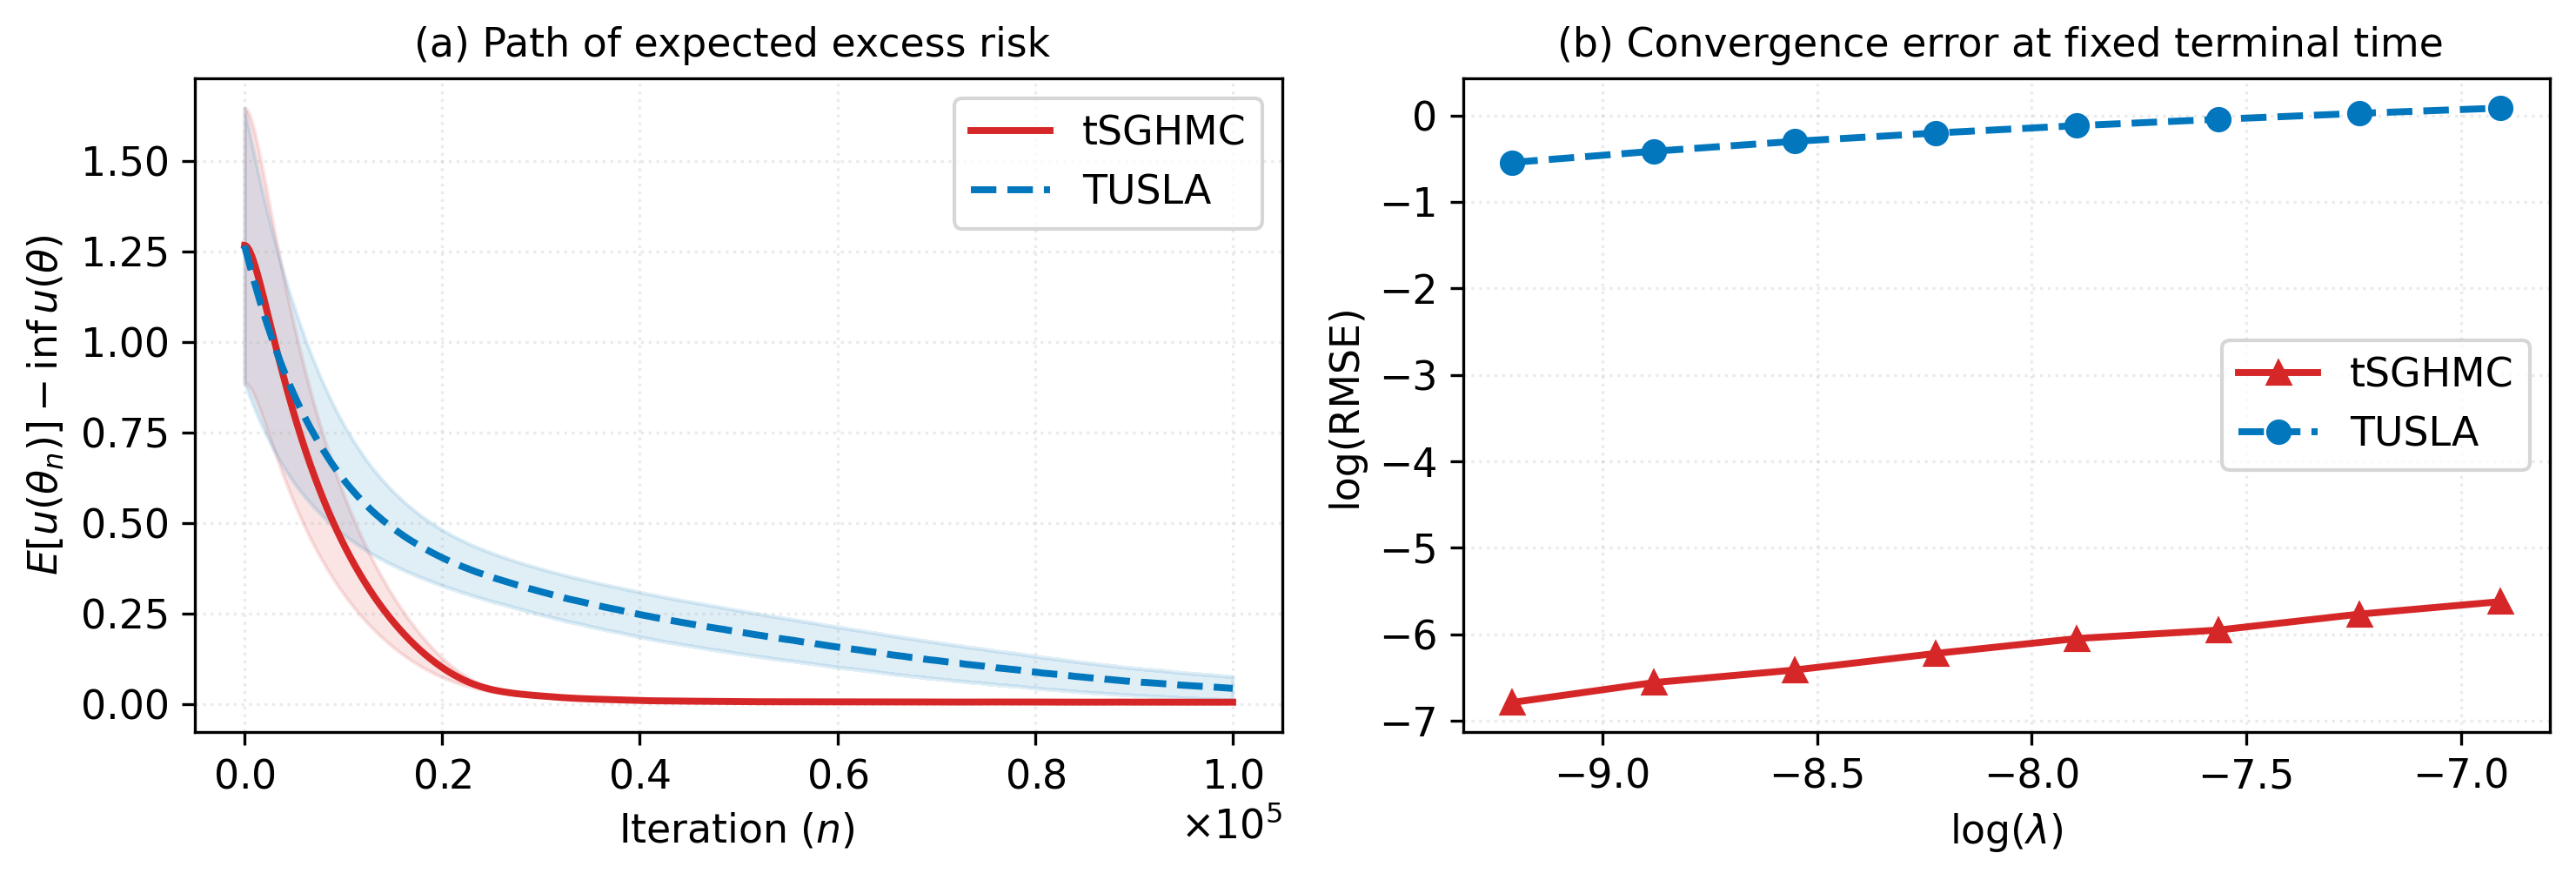

In [2]:
# ============================================================
# Experiment 2. Self-reference log-log plot for tSGHMC and TUSLA
# Combined figure for paper
# ============================================================

# ------------------------------
# Protocol aligned with Experiment 1
# ------------------------------
T_end = 10.0
h_min = 1e-4
h_max = 1e-3

log_h_grid = np.linspace(np.log(h_min), np.log(h_max), 8)
step_sizes = np.exp(log_h_grid)

lr_ref = 1e-5
n_particles_w2 = 30


def draw_coupled_inputs_by_steps(rep, n_steps):
    """Generate coupled initial condition and stochastic inputs."""
    rng_data = np.random.default_rng(150000 + rep)
    xs = sample_x(rng_data, n_steps)

    theta0 = np.random.default_rng(170000 + rep).normal(0.0, 1.0, size=d)

    return theta0, xs


def simulate_tusla_rep(rep, lr, T):
    """Simulate one TUSLA trajectory up to fixed physical time T."""
    n_steps = int(np.floor(T / lr))

    theta, xs = draw_coupled_inputs_by_steps(rep, n_steps)
    rng_alg = np.random.default_rng(160000 + rep)

    solver = TUSLA(H=H, lr=lr, beta=beta_shared, r=r_shared)

    for t in range(n_steps):
        theta = solver.step(theta, xs[t], rng=rng_alg)

    return theta


def simulate_tamed_rep(rep, lr, T):
    """Simulate one tSGHMC trajectory up to fixed physical time T."""
    n_steps = int(np.floor(T / lr))

    theta, xs = draw_coupled_inputs_by_steps(rep, n_steps)
    vol = np.zeros(d, dtype=float)
    rng_alg = np.random.default_rng(190000 + rep)

    solver = TamedSGHMC(H=H, lr=lr, gamma=gamma_tamed, beta=beta_shared, m=m_tamed, r=r_shared)

    for t in range(n_steps):
        theta, vol = solver.step(theta, vol, xs[t], rng=rng_alg)

    return theta


def run_tusla_fixed_time(lr, T, n_particles):
    """Run TUSLA particles at fixed physical time."""
    terminals = [
        simulate_tusla_rep(rep, lr, T)
        for rep in range(n_particles)
    ]

    return np.asarray(terminals, dtype=float)


def run_tamed_fixed_time(lr, T, n_particles):
    """Run tSGHMC particles at fixed physical time using serial execution."""
    terminals = [
        simulate_tamed_rep(rep, lr, T)
        for rep in range(n_particles)
    ]

    return np.asarray(terminals, dtype=float)


def empirical_w2(samples_a, samples_b):
    """Empirical RMSE-type W2 estimate using paired particles."""
    return np.sqrt(np.mean(np.sum((samples_a - samples_b) ** 2, axis=1)))


# ------------------------------
# Run Experiment 2
# ------------------------------
theta_ref_tusla = run_tusla_fixed_time(lr=lr_ref, T=T_end, n_particles=n_particles_w2)

theta_ref_tamed = run_tamed_fixed_time(lr=lr_ref, T=T_end, n_particles=n_particles_w2)

w2_tusla = []
w2_tamed = []

for lr in step_sizes:
    theta_tusla_lr = run_tusla_fixed_time(lr=lr, T=T_end, n_particles=n_particles_w2)

    theta_tamed_lr = run_tamed_fixed_time(lr=lr, T=T_end, n_particles=n_particles_w2)

    w2_tusla.append(empirical_w2(theta_tusla_lr, theta_ref_tusla))
    w2_tamed.append(empirical_w2(theta_tamed_lr, theta_ref_tamed))

w2_tusla = np.asarray(w2_tusla, dtype=float)
w2_tamed = np.asarray(w2_tamed, dtype=float)

log_h = np.log(step_sizes)
log_w2_tusla = np.log(w2_tusla)
log_w2_tamed = np.log(w2_tamed)

# Least-squares slopes for log-log trends
slope_tusla, intercept_tusla = np.polyfit(log_h, log_w2_tusla, deg=1)
slope_tamed, intercept_tamed = np.polyfit(log_h, log_w2_tamed, deg=1)

trend_tusla = intercept_tusla + slope_tusla * log_h
trend_tamed = intercept_tamed + slope_tamed * log_h


print("Experiment 2 W2 empirical values:")
for h, wu, wm in zip(step_sizes, w2_tusla, w2_tamed):
    print(
        f"  step size={h:.2e}, "
        f"W2_TUSLA_self={wu:.6e}, "
        f"W2_tSGHMC_self={wm:.6e}"
    )

print()
print(f"Estimated log-log slope (TUSLA self-reference):  {slope_tusla:.6f}")
print(f"Estimated log-log slope (tSGHMC self-reference): {slope_tamed:.6f}")


# ============================================================
# Combined figure for paper: side-by-side subplots
# Left: expected excess risk from Experiment 1
# Right: self-reference log-log from Experiment 2
# ============================================================

plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), dpi=300)

# ---------- Left panel: Expected excess risk ----------
ax = axes[0]

ax.plot(iters, mean_excess_tamed, color="#d62728", linewidth=1.9, label="tSGHMC")
ax.fill_between(iters, lb_tamed, ub_tamed, color='#d62728', alpha=0.12)
ax.plot(iters, mean_excess_tusla, color='#0277bd', linestyle='--', linewidth=1.9, label='TUSLA')
ax.fill_between(iters, lb_tusla, ub_tusla, color='#0277bd', alpha=0.12)

ax.set_xlabel(r"Iteration ($n$) ")
ax.set_ylabel(r"$E[u(\theta_n)]-\inf u( \theta)$")
ax.set_title("(a) Path of expected excess risk ")
ax.grid(alpha=0.25, linestyle=":")
ax.legend(frameon=True)

# Use scientific notation on iteration axis
sf_iter = ScalarFormatter(useMathText=True)
sf_iter.set_scientific(True)
sf_iter.set_powerlimits((0, 0))
ax.xaxis.set_major_formatter(sf_iter)
ax.ticklabel_format(axis="x", style="sci", scilimits=(0, 0))


# ---------- Right panel: Self-reference log-log ----------
ax = axes[1]

ax.plot(log_h, log_w2_tamed, color="#d62728", marker="^", linewidth=1.9, markersize=6, label="tSGHMC")
ax.plot(log_h, log_w2_tusla, color="#0277bd", marker="o", linestyle="--", linewidth=1.9, markersize=6, label="TUSLA")

ax.set_xlabel(r"$\log(\lambda)$")
ax.set_ylabel("log(RMSE)")
ax.set_title("(b) Convergence error at fixed terminal time ")
ax.grid(alpha=0.25, linestyle=":")
ax.legend(frameon=True, loc="best")

fig.tight_layout()
plt.show()

# Optional: save high-resolution figure for paper insertion
# fig.savefig("Example2_Artificial.png", dpi=220, bbox_inches="tight")